In [1]:
import warnings
from collections import Counter, defaultdict
from typing import DefaultDict, Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

SEED = 42
RNG = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (7, 3.5), "font.size": 11})


# n-граммные языковые модели

Языковая модель задаёт вероятности последовательностей токенов. В этом семинаре мы соберём **классическую n-граммную** модель по счётчикам на корпусе: оценим $P(w_t \mid \text{контекст})$ при фиксированной длине контекста, посмотрим на **перплексию**, **сглаживание Лапласа** и **Kneser–Ney**, и сгенерируем короткий текст.

Теория и обозначения подробнее — в конспекте [lm.md](lm.md). Про токенизацию и датасет **20 Newsgroups** см. [text_preprocessing_and_vectorization.ipynb](text_preprocessing_and_vectorization.ipynb) (те же четыре категории и `remove=('headers','footers','quotes')`).

In [2]:
NEWSGROUP_CATEGORIES: tuple[str, ...] = (
    "alt.atheism",
    "soc.religion.christian",
    "comp.graphics",
    "sci.med",
)
bunch_20ng_train = fetch_20newsgroups(
    subset="train",
    categories=list(NEWSGROUP_CATEGORIES),
    shuffle=True,
    random_state=SEED,
    remove=("headers", "footers", "quotes"),
)
bunch_20ng_test = fetch_20newsgroups(
    subset="test",
    categories=list(NEWSGROUP_CATEGORIES),
    shuffle=True,
    random_state=SEED,
    remove=("headers", "footers", "quotes"),
)


Сначала разобьем сырой текст на токены (`nltk.word_tokenize`), приведем к нижнему регистру и склеим пробелами — одна строка на документ.

In [3]:
def tokenize_document(text: str, *, lowercase: bool = True) -> str:
    raw = text.lower() if lowercase else text
    toks = word_tokenize(raw)
    return " ".join(toks)


In [4]:
raw_train = list(bunch_20ng_train.data)
raw_test = list(bunch_20ng_test.data)
max_train, max_test = 900, 300
train_lines = [tokenize_document(t) for t in raw_train[:max_train]]
test_lines = [tokenize_document(t) for t in raw_test[:max_test]]
train_topic_ids: np.ndarray = np.asarray(
    bunch_20ng_train.target[:max_train], dtype=np.int64
)
test_topic_ids: np.ndarray = np.asarray(
    bunch_20ng_test.target[:max_test], dtype=np.int64
)
newsgroup_target_names: tuple[str, ...] = tuple(bunch_20ng_train.target_names)
y_train_full: np.ndarray = np.asarray(bunch_20ng_train.target, dtype=np.int64)
len(train_lines), len(test_lines)

(900, 300)

In [5]:
train_lines[7]

": ) no ... i was one of the lucky ones . very little acne as a teenager . i did n't have any luck with clearasil . even though my skin gets oily it really only gets miserable pimples when it 's dry . frequent lukewarm water rinses on the face might help . getting the scalp thing under control might help ( that could be as simple as submerging under the bathwater till it 's softened and washing it out ) . taking a one a day vitamin/mineral might help . i 've heard iodine causes trouble and that it is used in fast food restaurants to sterilize equipment which might be where the belief that greasy foods cause acne came from . i notice grease on my face , not immediately removed will cause acne ( even from eating meat ) . keeping hair rinse , mousse , dip , and spray off the face will help . warm water bath soaks or cloths on the face to soften the oil in the pores will help prevent blackheads . body oil is hydrophilic , loves water and it softens and washes off when it has a chance . tha

## N-граммы

Для начала соберем статистики по корпусу: подсчитаем, какие у нас есть n-граммы. После подсчёта n-грамм построим таблицу условных вероятностей. 

Учтем специальные токены: 
- `UNK` дополняет короткий контекст до длины $(n-1)$, 
- `EOS` добавляется в конец каждой строки (предсказываем и его). Для каждой позиции считаем префикс из $(n-1)$ токенов и обновляем счётчик «префикс → следующий токен».


baseline-оценка для вероятностей:

$$P(w_t \mid h) = \frac{C(h, w_t)}{\sum_{\hat w} C(h, \hat w)}.$$

Марковское приближение (n-граммы):

$$P(w_t \mid w_1,\ldots,w_{t-1}) \approx P(w_t \mid w_{t-n+1},\ldots,w_{t-1}).$$

Для корпуса из документов (строк токенов) оценка частоты n-граммы $(w_1,\ldots,w_n)$:

$$C(w_1,\ldots,w_n) = \sum_{\text{документы}} \sum_{\text{позиции}} \mathbf{1}[w_{i-n+1:i+1} = (w_1,\ldots,w_n)].$$


In [6]:
UNK = "_UNK_"
EOS = "_EOS_"


def count_ngrams(
    lines: Iterable[str],
    n: int,
) -> DefaultDict[tuple[str, ...], Counter[str]]:
    counts: DefaultDict[tuple[str, ...], Counter[str]] = defaultdict(Counter)
    pad = n - 1
    for line in lines:
        toks = line.split()
        seq = list(toks)
        seq.append(EOS)
        for i in range(len(seq)):
            pref_list: list[str] = []
            for j in range(pad):
                idx = i - pad + j
                pref_list.append(UNK if idx < 0 else seq[idx])
            prefix = tuple(pref_list)
            w = seq[i]
            counts[prefix][w] += 1 # It's equivalent to the count of n-gram itself
    return counts


Посмотрим, как работает подсчет:

In [7]:
def conditional_counts_to_ngrams(
    cond: DefaultDict[tuple[str, ...], Counter[str]],
) -> Counter[tuple[str, ...]]:
    out: Counter[tuple[str, ...]] = Counter()
    for pref, ctr in cond.items():
        for w, c in ctr.items():
            out[pref + (w,)] += c
    return out


def ngram_table(
    ctr: Counter[tuple[str, ...]],
    *,
    k: int,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for ng, c in ctr.most_common(k):
        rows.append({"ngram": " ".join(ng), "count": c})
    return pd.DataFrame(rows)


synth_lines = [
    "the cat sat on the mat near the door",
    "the dog ran on the beach while the sun set",
    "cats and dogs are common pets in many homes",
    "on the mat the cat slept peacefully",
]
big_synth = conditional_counts_to_ngrams(count_ngrams(synth_lines, 2))
tri_synth = conditional_counts_to_ngrams(count_ngrams(synth_lines, 3))
display(ngram_table(big_synth, k=8))
display(ngram_table(tri_synth, k=8))



,ngram,count
0,on the,3
1,_UNK_ the,2
2,the cat,2
3,the mat,2
4,_UNK_ cats,1
5,_UNK_ on,1
6,the door,1
7,the dog,1


,ngram,count
0,_UNK_ _UNK_ the,2
1,on the mat,2
2,_UNK_ _UNK_ cats,1
3,_UNK_ _UNK_ on,1
4,_UNK_ the cat,1
5,_UNK_ the dog,1
6,the cat sat,1
7,the cat slept,1


То же самое проделаем на нашем датасете и заодно посмотрим, какие n-граммы типичны для разных топиков.

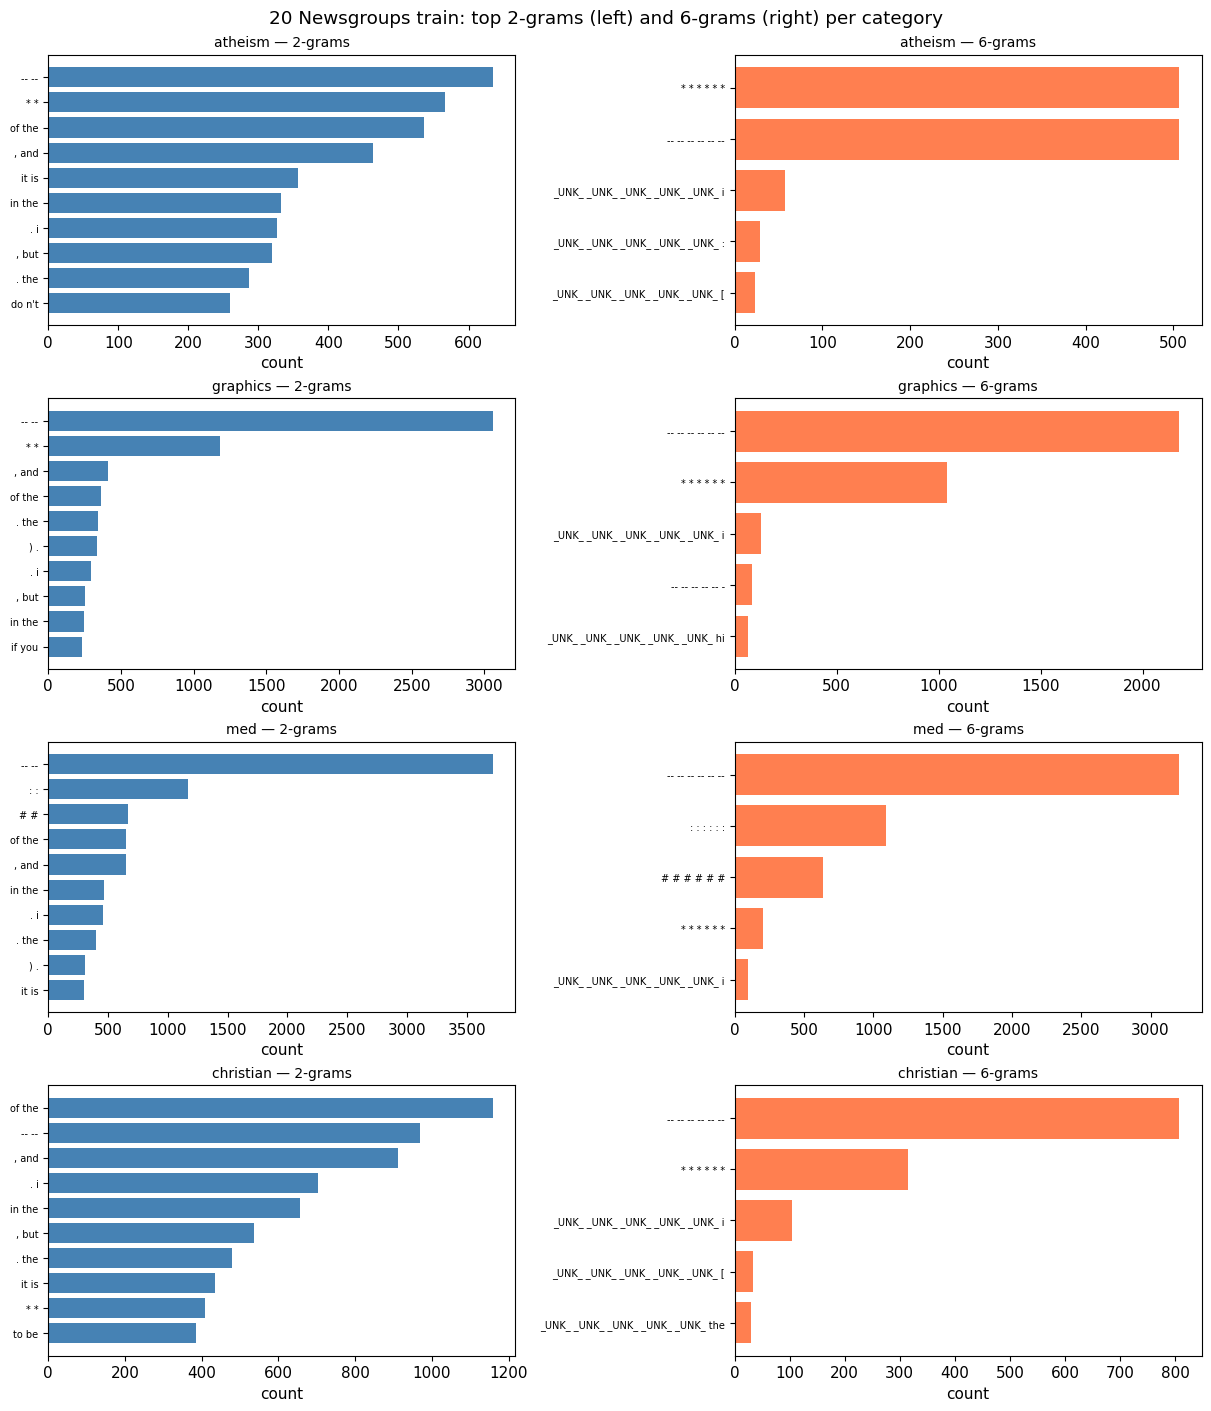

In [8]:
y_name: np.ndarray = np.asarray(
    [newsgroup_target_names[i] for i in y_train_full],
    dtype=object,
)
tokenized_ng: list[str] = [tokenize_document(t) for t in bunch_20ng_train.data]
(y_train_full.shape, y_name.shape, len(tokenized_ng))

ngrams_1 = 2
ngrams_2 = 6

fig, axes = plt.subplots(
    len(newsgroup_target_names),
    2,
    figsize=(12, 14),
    constrained_layout=True,
)
for ci, cname in enumerate(newsgroup_target_names):
    short = cname.split(".")[-1]
    lines_cat = [tokenized_ng[i] for i in np.flatnonzero(y_train_full == ci)]
    c2 = count_ngrams(lines_cat, ngrams_1)
    c3 = count_ngrams(lines_cat, ngrams_2)
    big_cat = conditional_counts_to_ngrams(c2)
    tri_cat = conditional_counts_to_ngrams(c3)
    top_bi = big_cat.most_common(10)
    top_tri = tri_cat.most_common(5)
    labels_bi = [" ".join(ng) for ng, _ in top_bi]
    counts_bi = [c for _, c in top_bi]
    labels_tri = [" ".join(ng) for ng, _ in top_tri]
    counts_tri = [c for _, c in top_tri]
    axes[ci, 0].barh(range(len(labels_bi)), counts_bi, color="steelblue")
    axes[ci, 0].set_yticks(range(len(labels_bi)))
    axes[ci, 0].set_yticklabels(labels_bi, fontsize=7)
    axes[ci, 0].invert_yaxis()
    axes[ci, 0].set_title(f"{short} — {ngrams_1}-grams", fontsize=10)
    axes[ci, 0].set_xlabel("count")
    axes[ci, 1].barh(range(len(labels_tri)), counts_tri, color="coral")
    axes[ci, 1].set_yticks(range(len(labels_tri)))
    axes[ci, 1].set_yticklabels(labels_tri, fontsize=7)
    axes[ci, 1].invert_yaxis()
    axes[ci, 1].set_title(f"{short} — {ngrams_2}-grams", fontsize=10)
    axes[ci, 1].set_xlabel("count")
plt.suptitle(f"20 Newsgroups train: top {ngrams_1}-grams (left) and {ngrams_2}-grams (right) per category")
plt.show()



In [9]:
def _normalize_prefix(prefix_tokens: Sequence[str], n: int) -> tuple[str, ...]:
    """ Паддинг до длины n-gram-1"""
    pad = n - 1
    pt = list(prefix_tokens[-pad:]) if pad else []
    if len(pt) < pad:
        pt = [UNK] * (pad - len(pt)) + pt
    return tuple(pt)

class NGramLanguageModel:
    def __init__(self, n: int) -> None:
        if n < 1:
            raise ValueError("n must be >= 1")
        self.n = n
        self.probs: DefaultDict[tuple[str, ...], dict[str, float]] = defaultdict(dict)

    def fit(self, lines: Sequence[str]):
        counts = count_ngrams(lines, self.n)
        self.probs = defaultdict(dict)
        for prefix, ctr in counts.items():
            total = sum(ctr.values())
            if total == 0:
                continue
            self.probs[prefix] = {w: ctr[w] / total for w in ctr}
        return self

    def get_possible_next_tokens(self, prefix: str) -> Mapping[str, float]:
        tokens = prefix.split()
        pref = _normalize_prefix(tokens, self.n)
        return self.probs.get(pref, {})

    def get_next_token_prob(self, prefix: str, next_token: str) -> float:
        return float(self.get_possible_next_tokens(prefix).get(next_token, 0.0))


Ниже на игрушечном корпусе оценим биграммы и выведем распределение после контекста **the** таблицей.

In [10]:
toy_train = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "the cat and the dog",
]
toy_train_tok = [" ".join(word_tokenize(s.lower())) for s in toy_train]
lm2 = NGramLanguageModel(n=2).fit(toy_train_tok)
dist = dict(lm2.get_possible_next_tokens("the"))
display(pd.DataFrame([{"w": k, "P(w|the)": v} for k, v in sorted(dist.items())]))

,w,P(w|the)
0,cat,0.333333
1,dog,0.333333
2,log,0.166667
3,mat,0.166667


Проверим, будет ли последнее слово из n-граммы лежать в списке вероятных для n-1-граммы. 

In [11]:
TOP_K = 10
n_ng = 4
NUM_SAMPLE_GRAMS = 4


def _top_k_probs_df(lm: NGramLanguageModel, prefix: str, k: int) -> pd.DataFrame:
    dist = dict(lm.get_possible_next_tokens(prefix))
    ranked = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:k]
    return pd.DataFrame(
        [{"rank": r + 1, "w": w, "P(w|context)": p} for r, (w, p) in enumerate(ranked)]
    )


def _gram_has_word_tokens(gram: tuple[str, ...]) -> bool:
    words = {t.lower() for t in gram if any(ch.isalpha() for ch in t)}
    return len(words) >= len(gram) - 1 


def _collect_frequent_nplus1_grams(
    lines: Sequence[str],
    order_n: int,
    num_grams: int,
) -> list[tuple[str, ...]]:
    counts = count_ngrams(lines, order_n)
    big_cat = conditional_counts_to_ngrams(counts)
    top_grams = big_cat.most_common(order_n * 4)
    filtered = [gram[0]  for gram in top_grams if _gram_has_word_tokens(gram[0])]
    return filtered[::3][:order_n]


def _display_frequent_gram_windows(
    lm: NGramLanguageModel,
    model_name: str,
    order_n: int,
    *,
    top_k: int = 10,
    num_grams: int = 4,
) -> None:
    ctx = order_n - 1
    grams = _collect_frequent_nplus1_grams(train_lines, order_n, num_grams=num_grams)
    for gi, gram in enumerate(grams, start=1):
        gstr = " ".join(gram)
        display(Markdown(f"*Грамма {gi}:* `{gstr}`"))
        pref_first = " ".join(gram[:ctx]) if ctx > 0 else ""
        pref_last = " ".join(gram[-ctx:]) if ctx > 0 else ""
        print(f"окно 1 (первые n-1 токенов): `{pref_first if pref_first else '<empty>'}`")
        display(_top_k_probs_df(lm, pref_first, top_k))
        print(f"окно 2 (последние n-1 токенов): `{pref_last if pref_last else '<empty>'}`")
        display(_top_k_probs_df(lm, pref_last, top_k))
        print()


lm_ng = NGramLanguageModel(n=n_ng).fit(train_lines)
_display_frequent_gram_windows(lm_ng, "n-граммы", n_ng, top_k=TOP_K, num_grams=NUM_SAMPLE_GRAMS)


*Грамма 1:* `. i do n't`

окно 1 (первые n-1 токенов): `. i do`


,rank,w,P(w|context)
0,1,n't,0.784615
1,2,not,0.123077
2,3,think,0.030769
3,4,have,0.030769
4,5,however,0.015385
5,6,like,0.015385


окно 2 (последние n-1 токенов): `i do n't`


,rank,w,P(w|context)
0,1,know,0.236994
1,2,think,0.202312
2,3,have,0.092486
3,4,believe,0.063584
4,5,see,0.052023
5,6,like,0.023121
6,7,want,0.017341
7,8,mean,0.017341
8,9,agree,0.011561
9,10,claim,0.011561


*Грамма 2:* `gordon banks n3jxp |`

окно 1 (первые n-1 токенов): `gordon banks n3jxp`


,rank,w,P(w|context)
0,1,|,1.0


окно 2 (последние n-1 токенов): `banks n3jxp |`


,rank,w,P(w|context)
0,1,``,1.0


## Генерация и температура

Текст генерируется, пока не выпал `EOS` или не достигнута максимальная длина, авторегрессионно: сэмплируем $w \sim P(\cdot \mid \text{префикс})$ для каждого нового шага, постепенно добавляя в префикс нагенерированные слова. Вместо жадного argmax можно брать распределение с **температурой** $\tau > 0$ и семплировать из этого распределения:

$$\tilde p_i \propto p_i^{1/\tau}, \qquad \sum_i \tilde p_i = 1.$$

При $\tau \to 0$ чаще выбираются пики; при $\tau > 1$ распределение размывается. На синтетике сравним вероятности в таблице; на Newsgroups — короткая генерация.

In [12]:
def get_next_token(
    lm: NGramLanguageModel,
    prefix: str,
    rng: np.random.Generator,
    *,
    temperature: float = 1.0,
) -> str:
    dist = dict(lm.get_possible_next_tokens(prefix))
    if not dist:
        return EOS
    tokens = list(dist.keys())
    probs = np.array([dist[t] for t in tokens], dtype=np.float64)
    if temperature == 0.0:
        best = int(np.argmax(probs))
        return tokens[best]
    tau = max(temperature, 1e-12)
    logits = np.log(np.clip(probs, 1e-300, 1.0)) / tau
    ex = np.exp(logits - np.max(logits))
    p = ex / ex.sum()
    idx = int(rng.choice(len(tokens), p=p))
    return tokens[idx]


На биграммной модели `lm2` и префиксе «the» сравним исходные $p_i$ и взвешенные $\tilde p_i \propto p_i^{1/\tau}$ для нескольких температур — **таблица**.

In [13]:
prefix = "the"
temps = [0.25, 0.75, 1.5]
base = np.array(list(dist.values()), dtype=np.float64)
keys = list(dist.keys())
rows = []
for tau in temps:
    logits = np.log(np.clip(base, 1e-300, 1.0)) / max(tau, 1e-12)
    ex = np.exp(logits - np.max(logits))
    tilde = ex / ex.sum()
    for k, p, t in zip(keys, base, tilde):
        rows.append({"tau": tau, "w": k, "p": p, "tilde_p": t})
display(pd.DataFrame(rows).pivot(index="w", columns="tau", values="tilde_p").round(4))

tau,0.25,0.75,1.50
w,,,
cat,0.4706,0.3579,0.3068
dog,0.4706,0.3579,0.3068
log,0.0294,0.1421,0.1932
mat,0.0294,0.1421,0.1932


Проверим, действительно ли слова семплируются с этими вероятностями?

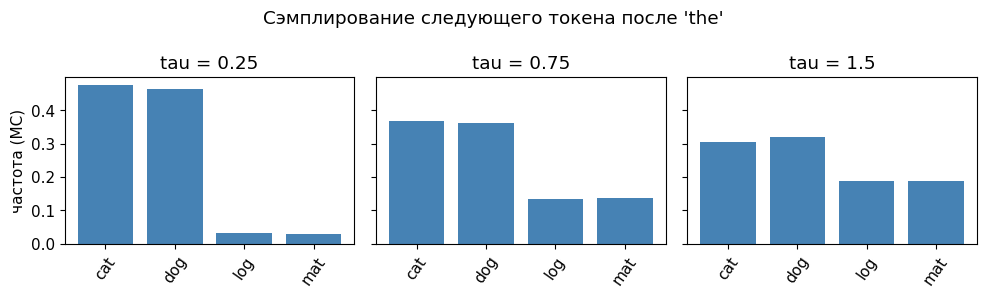

In [14]:
mc = 4000
fig, axes = plt.subplots(1, len(temps), figsize=(10, 3), sharey=True)
for ax, tau in zip(axes, temps):
    cts: dict[str, int] = {}
    for _ in range(mc):
        t = get_next_token(lm2, prefix, RNG, temperature=tau)
        cts[t] = cts.get(t, 0) + 1
    keys_mc = sorted(cts.keys())
    ax.bar(keys_mc, [cts[k] / mc for k in keys_mc], color="steelblue")
    ax.set_title(f"tau = {tau}")
    ax.tick_params(axis="x", rotation=55)
axes[0].set_ylabel("частота (MC)")
plt.suptitle(f"Сэмплирование следующего токена после '{prefix}'")
plt.tight_layout()
plt.show()

При обычной генерации многие контексты ни разу не встречались в обучении: условное распределение для префикса пустое, и `get_possible_next_tokens` возвращает `{}`. Тогда сэмплер сразу выдаёт `EOS` — цепочка обрывается. При ненулевом же распределении вероятности все равно часто очень пиковые, что приводит к повторам или обрывающимуся тексту.

Проверим, так ли это: возьмем биграммы из `train_lines`, при этом проверим два префикса — типичный (`the`) и заведомо редкий, не встречавшийся как контекст в обучении.


In [15]:
TOP_K_PROBS = 10
N_GEN_EACH = 4
GEN_MAX_LEN = 40
TAU_SAMPLE_GEN = 0.85


def _generate_line(
    lm: NGramLanguageModel,
    prefix: str,
    rng: np.random.Generator,
    *,
    max_len: int,
    temperature: float,
) -> str:
    out = prefix
    for _ in range(max_len):
        w = get_next_token(lm, out, rng, temperature=temperature)
        out = out + " " + w
        if w == EOS:
            break
    return out.replace(EOS, "<EOS>")


def _print_model_block(
    lm: NGramLanguageModel,
    model_name: str,
    prefixes: list[str],
    tag: int,
) -> None:
    for pref in prefixes:
        print(f"{model_name}, префикс `{pref}` — топ-{TOP_K_PROBS} следующих токенов")
        display(_top_k_probs_df(lm, pref, TOP_K_PROBS))
        print(f"жадно (τ=0), {N_GEN_EACH} прогона:")
        for i in range(N_GEN_EACH):
            rr = np.random.default_rng(SEED + 100 * tag + i)
            print(f"  {i + 1}.", _generate_line(lm, pref, rr, max_len=GEN_MAX_LEN, temperature=0.0))
        print(f"семплирование (τ={TAU_SAMPLE_GEN}), {N_GEN_EACH} прогона:")
        for i in range(N_GEN_EACH):
            rr = np.random.default_rng(SEED + 100 * tag + 50 + i)
            print(
                f"  {i + 1}.",
                _generate_line(lm, pref, rr, max_len=GEN_MAX_LEN, temperature=TAU_SAMPLE_GEN),
            )
        print()


In [16]:
n = 2
gen_baseline_ng = NGramLanguageModel(n=n).fit(train_lines)
prefixes_ng = ["the", "synchrophasotrone"]
_print_model_block(gen_baseline_ng, f"{n}-грамма", prefixes_ng, tag=1)
d_rich = gen_baseline_ng.get_possible_next_tokens(prefixes_ng[0])
d_sparse = gen_baseline_ng.get_possible_next_tokens(prefixes_ng[1])
print(f"|next после 'the'| = {len(d_rich)}, |next после редкого| = {len(d_sparse)}")
_display_frequent_gram_windows(gen_baseline_ng, "топ вероятностей", n, top_k=TOP_K_PROBS, num_grams=4)


2-грамма, префикс `the` — топ-10 следующих токенов


,rank,w,P(w|context)
0,1,same,0.014245
1,2,bible,0.012863
2,3,``,0.009248
3,4,church,0.009142
4,5,most,0.008079
5,6,first,0.007654
6,7,other,0.007441
7,8,only,0.006803
8,9,time,0.006591
9,10,world,0.006485


жадно (τ=0), 4 прогона:
  1. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  2. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  3. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  4. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
семплирование (τ=0.85), 4 прогона:
  1. the rest you can be difficult to the mouse . it will be glad it . <EOS>
  2. the united states are indeed , as some cases . by andrew kille reponded -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- - the action . look on . if you do what
  3. the regular issue of christianity . martin ... ] and neither side . it was in and traditional '' 3

""


жадно (τ=0), 4 прогона:
  1. synchrophasotrone <EOS>
  2. synchrophasotrone <EOS>
  3. synchrophasotrone <EOS>
  4. synchrophasotrone <EOS>
семплирование (τ=0.85), 4 прогона:
  1. synchrophasotrone <EOS>
  2. synchrophasotrone <EOS>
  3. synchrophasotrone <EOS>
  4. synchrophasotrone <EOS>

|next после 'the'| = 3161, |next после редкого| = 0


...

*Грамма 2:* `in the`

окно 1 (первые n-1 токенов): `in`


,rank,w,P(w|context)
0,1,the,0.238281
1,2,a,0.060872
2,3,this,0.033529
3,4,my,0.020508
4,5,fact,0.018229
5,6,his,0.013997
6,7,your,0.012370
7,8,general,0.010417
8,9,advance,0.009440
9,10,their,0.009115


окно 2 (последние n-1 токенов): `the`


,rank,w,P(w|context)
0,1,same,0.014245
1,2,bible,0.012863
2,3,``,0.009248
3,4,church,0.009142
4,5,most,0.008079
5,6,first,0.007654
6,7,other,0.007441
7,8,only,0.006803
8,9,time,0.006591
9,10,world,0.006485


## Перплексия

**Перплексия** измеряет, насколько модель «удивлена» данными: чем ниже, тем лучше согласование (при честном сравнении моделей). По корпусу из $N$ токенов:

$$\mathrm{PP} = \exp\left(-\frac{1}{N} \sum_{t=1}^{N} \log P(w_t \mid \ldots)\right).$$

Для вычисления используются лог-вероятности в **натуральном** логарифме, затем берется экспонента от их суммы. Для нулевых вероятностей в случае базовой модели используют нижнюю границу `min_logprob`, чтобы не получить $-\infty$.

**Важно:** это технический приём для численной устойчивости: фиктивная нижняя граница на $\log P$ не превращает нашу модель в корректную вероятностную модель на новых n-граммах. Такую перплексию нельзя напрямую сопоставлять с перплексией сглаженных моделей (Лаплас, KN), где масса на неизвестные события задана явно — для сравнения нужна одна и та же схема оценки $P(w\mid\text{контекст})$.


In [17]:
def perplexity(
    lm: NGramLanguageModel,
    lines: Sequence[str],
    *,
    min_logprob: float = np.log(10 ** -50.0),
    log: str = "natural",
) -> float:
    total_ll = 0.0
    n_tokens = 0
    for line in lines:
        toks = line.split()
        toks.append(EOS)
        ctx: list[str] = []
        for w in toks:
            pref = " ".join(ctx)
            lp = np.log(max(lm.get_next_token_prob(pref, w), 1e-300))
            if lp < min_logprob:
                lp = min_logprob
            total_ll += lp
            n_tokens += 1
            ctx.append(w)
    if n_tokens == 0:
        return float("inf")
    mean_nll = -total_ll / n_tokens
    if log == "log2":
        mean_bits = mean_nll / np.log(2.0)
        return float(2 ** mean_bits)
    return float(np.exp(mean_nll))


Проверим, как меняется перплексия при увеличении n.

,n,perplexity_train
0,1,7.5094
1,2,1.7118
2,3,1.3545
3,4,1.2638


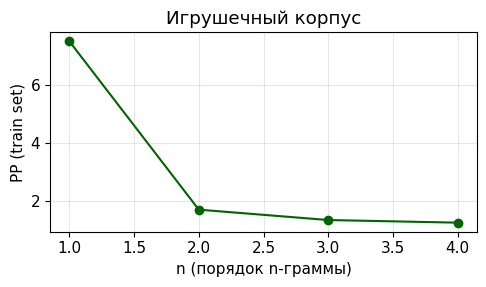

In [18]:
orders = [1, 2, 3, 4]
pp_train = [perplexity(NGramLanguageModel(n=k).fit(toy_train_tok), toy_train_tok) for k in orders]
df_pp_toy = pd.DataFrame({"n": orders, "perplexity_train": pp_train})
display(df_pp_toy.round(4))
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(df_pp_toy["n"], df_pp_toy["perplexity_train"], "o-", color="darkgreen")
ax.set_xlabel("n (порядок n-граммы)")
ax.set_ylabel("PP (train set)")
ax.set_title("Игрушечный корпус")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Фраза с редкими n-граммами: перплексия большая, но конечная при `min_logprob`.

In [19]:
lm3_toy = NGramLanguageModel(n=5).fit(toy_train_tok)
ood = ["the jabberwock , with eyes of flame , "]
pp_ood = perplexity(lm3_toy, [tokenize_document(s) for s in ood])
print(f"perplexity (OOD фраза, токенизировано): {pp_ood:.2e}")

perplexity (OOD фраза, токенизировано): 2.78e+44


Проверим перплексию на тесте:

In [20]:
pool = list(raw_train[:max_train])
tr_raw, te_raw = train_test_split(pool, test_size=0.25, random_state=SEED)
tr_lines = [tokenize_document(t) for t in tr_raw]
te_lines = [tokenize_document(t) for t in te_raw]
n = 3
baseline = NGramLanguageModel(n=n).fit(tr_lines)
pp_baseline_test = perplexity(baseline, te_lines)
print(f" {n}-gram, perplexity(test) ≈ {pp_baseline_test:.4e}")

 3-gram, perplexity(test) ≈ 2.9203e+39


Задание: Посчитайте перплексию на тестовом датасете. Сделайте вывод, меняется ли она также, как на трейне.

In [21]:
# перплексия на train и test для разных n

orders = [1, 2, 3, 4]

pp_train = []
pp_test = []

for n in orders:
    lm = NGramLanguageModel(n=n).fit(tr_lines)
    
    pp_train.append(perplexity(lm, tr_lines))
    pp_test.append(perplexity(lm, te_lines))

df_pp = pd.DataFrame({
    "n": orders,
    "perplexity_train": pp_train,
    "perplexity_test": pp_test
})

df_pp

,n,perplexity_train,perplexity_test
0,1,856.479021,1.037984e+06
1,2,38.966230,3.716955e+22
2,3,3.317218,2.920280e+39
3,4,1.311312,7.062058e+45


**Выводы:**
- На обучающей выборке perplexity уменьшается при увеличении порядка n-граммы.
- На тестовой выборке наблюдается противоположная картина: perplexity резко растёт при увеличении n.

То есть можно сделать вывод, что рост порядка n-граммы улучшает качество на train, но без сглаживания ухудшает обобщение на test. По сути - переобучение.

## Сглаживание Лапласа (additive)

Чтобы не присваивать нулевую вероятность ненаблюдённым n-граммам, используют **сглаживание Лапласа** (add-$\delta$):

$$P(w \mid h) = \frac{C(h,w) + \delta}{\sum_{\hat w} C(h,\hat w) + \delta \, |V|}.$$

Cравним базовую модель и сглаженную по Лапласу:

In [22]:
class LaplaceLanguageModel(NGramLanguageModel):
    def __init__(self, n: int, delta: float = 1.0) -> None:
        if delta <= 0:
            raise ValueError("delta must be positive")
        super().__init__(n)
        self.delta = delta

    def fit(self, lines: Sequence[str]):
        self._counts = count_ngrams(lines, self.n)
        self.vocab = {w for ctr in self._counts.values() for w in ctr}
        self.probs = defaultdict(dict)
        return self

    def get_possible_next_tokens(self, prefix: str) -> Mapping[str, float]:
        tokens = prefix.split()
        pref = _normalize_prefix(tokens, self.n)
        ctr = self._counts.get(pref)
        if not self.vocab:
            return {}
        if ctr is None or sum(ctr.values()) == 0:
            u = 1.0 / len(self.vocab)
            return {w: u for w in self.vocab}
        # recompute on the go, not store
        total = float(sum(ctr.values()) + self.delta * len(self.vocab)) 
        return {w: (ctr.get(w, 0) + self.delta) / total for w in self.vocab}

    def get_next_token_prob(self, prefix: str, next_token: str) -> float:
        tokens = prefix.split()
        pref = _normalize_prefix(tokens, self.n)
        ctr = self._counts.get(pref)
        if not self.vocab:
            return 0.0
        if ctr is None or sum(ctr.values()) == 0:
            return (1.0 / len(self.vocab)) if next_token in self.vocab else 0.0
        total = float(sum(ctr.values()) + self.delta * len(self.vocab))
        return (ctr.get(next_token, 0) + self.delta) / total


С **аддитивным сглаживанием** у каждого префикса есть ненулевое распределение по словарю, поэтому сэмплирование не останавливается из‑за пустого $P(\cdot \mid h)$ на ненаблюдённом контексте (как у базовой модели выше).


In [23]:
gen_lap = LaplaceLanguageModel(n=2, delta=0.01).fit(train_lines)
prefixes_ng = ["the", "QWRWDAD123122"]
_print_model_block(gen_lap, "Лаплас (δ=0.01, биграмма)", prefixes_ng, tag=2)
_display_frequent_gram_windows(gen_lap, "Лаплас (δ=0.01, биграмма): частые граммы", 2, top_k=TOP_K_PROBS, num_grams=4)


Лаплас (δ=0.01, биграмма), префикс `the` — топ-10 следующих токенов


,rank,w,P(w|context)
0,1,same,0.013952
1,2,bible,0.012599
2,3,``,0.009059
3,4,church,0.008955
4,5,most,0.007913
5,6,first,0.007497
6,7,other,0.007289
7,8,only,0.006664
8,9,time,0.006456
9,10,world,0.006352


жадно (τ=0), 4 прогона:
  1. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  2. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  3. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  4. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
семплирование (τ=0.85), 4 прогона:
  1. the future inflammatory displaying daughters telling half-truths i000702 673-735 jupiter.fnbc.com formation confusions schnapf cal absorbtion 5555 626-6372 third-party nickname benefits predictions toxic ames liquid-x 32768 skies asg thrid over-order charm al celebate nothingness 'oop-guild ataris term. excluded hermeneia conspiracy 68070

,rank,w,P(w|context)
0,1,brethren,0.00005
1,2,'53,0.00005
2,3,obedient,0.00005
3,4,man,0.00005
4,5,ultrasounds,0.00005
5,6,'old,0.00005
6,7,_anything_,0.00005
7,8,culture,0.00005
8,9,yoking,0.00005
9,10,disk-of-the-month,0.00005


жадно (τ=0), 4 прогона:
  1. QWRWDAD123122 brethren on the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  2. QWRWDAD123122 brethren on the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  3. QWRWDAD123122 brethren on the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  4. QWRWDAD123122 brethren on the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
семплирование (τ=0.85), 4 прогона:
  1. QWRWDAD123122 given 998-7857 texturemapped stone reimburse system blacks 673-735 jupiter.fnbc.com formation confusions schnapf cal absorbtion 5555 626-6372 third-party nickname benefits predictions toxic ames liquid-x 32768 skies asg thrid over-order charm al celebate not

...

*Грамма 2:* `in the`

окно 1 (первые n-1 токенов): `in`


,rank,w,P(w|context)
0,1,the,0.223849
1,2,a,0.057188
2,3,this,0.031500
3,4,my,0.019268
4,5,fact,0.017128
5,6,his,0.013152
6,7,your,0.011623
7,8,general,0.009789
8,9,advance,0.008871
9,10,their,0.008565


окно 2 (последние n-1 токенов): `the`


,rank,w,P(w|context)
0,1,same,0.013952
1,2,bible,0.012599
2,3,``,0.009059
3,4,church,0.008955
4,5,most,0.007913
5,6,first,0.007497
6,7,other,0.007289
7,8,only,0.006664
8,9,time,0.006456
9,10,world,0.006352


Также сравним базовый метод и сглаженный на синтетике

In [24]:
lap_toy = LaplaceLanguageModel(n=2, delta=0.5).fit(toy_train_tok)
rows = []
for w in sorted(lap_toy.vocab):
    rows.append(
        {
            "w": w,
            "baseline": dist.get(w, 0.0),
            "laplace": lap_toy.get_next_token_prob("the", w),
        }
    )
display(pd.DataFrame(rows).query("baseline > 0 or laplace > 0.01").head(12).round(6))

,w,baseline,laplace
0,_EOS_,0.000000,0.047619
1,and,0.000000,0.047619
2,cat,0.333333,0.238095
3,dog,0.333333,0.238095
4,log,0.166667,0.142857
5,mat,0.166667,0.142857
6,on,0.000000,0.047619
7,sat,0.000000,0.047619
8,the,0.000000,0.047619


Задание: реализуйте схему перехода к n-1 грамме, сравните со сглаживанием Лапласа

In [25]:
# p.s. "схему перехода к n-1 грамме" назову backoff

class BackoffLanguageModel:
    def __init__(self, n: int, alpha: float = 0.4) -> None:
        self.n = n
        self.alpha = alpha
        self.models = []

    def fit(self, lines: Sequence[str]):
        self.models = [
            NGramLanguageModel(n=k).fit(lines)
            for k in range(1, self.n + 1)
        ]
        return self

    def get_next_token_prob(self, prefix: str, next_token: str) -> float:
        tokens = prefix.split()

        for k in range(self.n, 0, -1):
            model = self.models[k - 1]
            cur_prefix = " ".join(tokens[-(k - 1):]) if k > 1 else ""

            prob = model.get_next_token_prob(cur_prefix, next_token)

            if prob > 0:
                return prob * (self.alpha ** (self.n - k))

        return 0.0

    def get_possible_next_tokens(self, prefix: str) -> Mapping[str, float]:
        tokens = prefix.split()

        for k in range(self.n, 0, -1):
            model = self.models[k - 1]
            cur_prefix = " ".join(tokens[-(k - 1):]) if k > 1 else ""

            dist = model.get_possible_next_tokens(cur_prefix)

            if len(dist) > 0:
                return dist

        return {}

In [26]:
orders = [1, 2, 3, 4]

rows = []

for n in orders:
    baseline = NGramLanguageModel(n=n).fit(tr_lines)
    laplace = LaplaceLanguageModel(n=n, delta=0.01).fit(tr_lines)
    backoff = BackoffLanguageModel(n=n, alpha=0.4).fit(tr_lines)

    rows.append({
        "n": n,
        "baseline_train": perplexity(baseline, tr_lines),
        "baseline_test": perplexity(baseline, te_lines),
        "laplace_train": perplexity(laplace, tr_lines),
        "laplace_test": perplexity(laplace, te_lines),
        "backoff_train": perplexity(backoff, tr_lines),
        "backoff_test": perplexity(backoff, te_lines),
    })

compare_pp = pd.DataFrame(rows)
compare_pp

,n,baseline_train,baseline_test,laplace_train,laplace_test,backoff_train,backoff_test
0,1,856.479021,1.037984e+06,856.481290,1.342168e+03,856.479021,1.037984e+06
1,2,38.966230,3.716955e+22,132.586291,2.403007e+03,38.966230,4.631009e+05
2,3,3.317218,2.920280e+39,120.022392,2.247409e+05,3.317218,7.028708e+05
3,4,1.311312,7.062058e+45,137.400641,4.617470e+06,1.311312,1.464913e+06


**Выводы:**

Базовая n-граммная модель без сглаживания показывает сильное переобучение.

Сглаживание Лапласа значительно снижает test perplexity по сравнению с baseline, так как задаёт ненулевую вероятность для ненаблюдавшихся слов.

Backoff-схема улучшает baseline для `n >= 2`, так как при неизвестном длинном контексте переходит к более короткому. Для `n=4` backoff оказался лучше Laplace на test, потому что не размывает вероятность по всему словарю, а использует более общие контексты.

## Kneser–Ney

Аддитивное сглаживание простое; **Kneser–Ney** вычитает абсолютный дисконт $\delta$ из ненулевых счётчиков и переносит массу на более короткий контекст (backoff). Униграмма в базе KN задаётся через продолжения: насколько часто токен появляется в новых контекстах.

Рекурсия (схематично):

$$P_{\mathrm{KN}}(w \mid h) = \frac{\max(0, C(h,w)-\delta)}{\sum_{\hat w} C(h,\hat w)} + \lambda_h \, P_{\mathrm{KN}}(w \mid h'),$$

где $h'$ — суффикс $h$ без первого токена, $\lambda_h$ подбирается из нормировки.

Ниже в коде — упрощённая учебная реализация (один порядок n-грамм, фиксированный $\delta$). Полный интерполированный Kneser–Ney с несколькими уровнями и обучаемыми дисконтами — отдельная тема, в продакшене (например, KenLM) используют именно такие схемы.

In [27]:
class KneserNeyLanguageModel(NGramLanguageModel):
    def __init__(self, n: int, delta: float = 0.75) -> None:
        if not (0.0 < delta < 1.0):
            raise ValueError("delta should lie in (0, 1)")
        super().__init__(n)
        self.delta = delta

    def fit(self, lines: Sequence[str]):
        self._lines = list(lines)
        self._counts = [
            count_ngrams(self._lines, order) for order in range(1, self.n + 1)
        ]
        self.vocab = self._build_vocab()
        self._p_cont = self._continuation_unigram()
        self.probs = defaultdict(dict)
        return self

    def _build_vocab(self) -> set[str]:
        v: set[str] = set()
        for cts in self._counts:
            for ctr in cts.values():
                v.update(ctr.keys())
        return v

    def _continuation_unigram(self) -> dict[str, float]:
        bi = self._counts[1]
        left_of: DefaultDict[str, set[str]] = defaultdict(set)
        for (w0,), ctr in bi.items():
            for w1 in ctr:
                if ctr[w1] > 0:
                    left_of[w1].add(w0)
        numer = {w: float(len(left_of[w])) for w in self.vocab}
        tot = sum(numer.values())
        if tot <= 0:
            u = 1.0 / max(len(self.vocab), 1)
            return {w: u for w in self.vocab}
        return {w: numer.get(w, 0.0) / tot for w in self.vocab}

    def _kn_prob(self, order: int, prefix: tuple[str, ...], w: str) -> float:
        if order == 1:
            return float(self._p_cont.get(w, 1e-300))
        idx = order - 1
        cts = self._counts[idx]
        ctr = cts.get(prefix)
        if ctr is None or sum(ctr.values()) == 0:
            shorter = prefix[1:] if len(prefix) > 1 else tuple()
            return self._kn_prob(order - 1, shorter, w)
        total = float(sum(ctr.values()))
        distinct = sum(1 for cw in ctr if ctr[cw] > 0)
        discounted = max(ctr.get(w, 0) - self.delta, 0.0) / total
        lam = (self.delta * distinct) / total
        shorter = prefix[1:] if len(prefix) > 1 else tuple()
        backoff = self._kn_prob(order - 1, shorter, w)
        return discounted + lam * backoff

    def get_next_token_prob(self, prefix: str, next_token: str) -> float:
        tokens = prefix.split()
        pref = _normalize_prefix(tokens, self.n)
        return self._kn_prob(self.n, pref, next_token)

    def get_possible_next_tokens(self, prefix: str) -> Mapping[str, float]:
        tokens = prefix.split()
        pref = _normalize_prefix(tokens, self.n)
        raw = {w: self._kn_prob(self.n, pref, w) for w in self.vocab}
        s = sum(raw.values())
        if s <= 0:
            u = 1.0 / len(self.vocab)
            return {w: u for w in self.vocab}
        return {w: raw[w] / s for w in self.vocab}


In [28]:
gen_kn_ng = KneserNeyLanguageModel(n=2, delta=0.75).fit(train_lines)
prefixes_ng = ["the", "zzzznonexistent123"]
_print_model_block(gen_kn_ng, "Kneser–Ney (δ=0.75, биграмма)", prefixes_ng, tag=3)
_display_frequent_gram_windows(gen_kn_ng, "Kneser–Ney (δ=0.75, биграмма): частые граммы", 2, top_k=TOP_K_PROBS, num_grams=4)


Kneser–Ney (δ=0.75, биграмма), префикс `the` — топ-10 следующих токенов


,rank,w,P(w|context)
0,1,same,0.014204
1,2,bible,0.012826
2,3,",",0.009798
3,4,``,0.009780
4,5,church,0.009144
5,6,.,0.008377
6,7,most,0.008170
7,8,first,0.007711
8,9,other,0.007600
9,10,only,0.006983


жадно (τ=0), 4 прогона:
  1. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  2. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  3. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
  4. the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot
семплирование (τ=0.85), 4 прогона:
  1. the choice is not me . i would have made a tied to keyboard events in light sources . you need to grab the son is involved which require vitamin a little understanding . however , it is a a good
  2. the also ryan bayne ) /2.0 ; the extra kelly maurice more difficult 's the screen any format . and support a lot more grave , and systems of

,rank,w,P(w|context)
0,1,",",0.038879
1,2,.,0.033241
2,3,and,0.016571
3,4,of,0.015227
4,5,to,0.013892
5,6,),0.013432
6,7,(,0.013378
7,8,in,0.012241
8,9,the,0.010843
9,10,is,0.009769


жадно (τ=0), 4 прогона:
  1. zzzznonexistent123 , and the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  2. zzzznonexistent123 , and the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  3. zzzznonexistent123 , and the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
  4. zzzznonexistent123 , and the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same as a lot of the same
семплирование (τ=0.85), 4 прогона:
  1. zzzznonexistent123 is the virus after the subject . sympathy graduate student work and the wrong , it . ( this card . developing we had already @ corps of voce before , but i can any more ( above on the
  2. zzzznonexistent123 and when you do not the bible for them . just our

...

*Грамма 2:* `in the`

окно 1 (первые n-1 токенов): `in`


,rank,w,P(w|context)
0,1,the,0.240258
1,2,a,0.061870
2,3,this,0.033894
3,4,my,0.020613
4,5,fact,0.018018
5,6,his,0.014006
6,7,your,0.012490
7,8,general,0.010213
8,9,that,0.009662
9,10,.,0.009494


окно 2 (последние n-1 токенов): `the`


,rank,w,P(w|context)
0,1,same,0.014204
1,2,bible,0.012826
2,3,",",0.009798
3,4,``,0.009780
4,5,church,0.009144
5,6,.,0.008377
6,7,most,0.008170
7,8,first,0.007711
8,9,other,0.007600
9,10,only,0.006983


Сравним модели, посчитав перплексию на тесте:

In [29]:
n = 5
mle_ng = NGramLanguageModel(n=n).fit(tr_lines)
lap_ng = LaplaceLanguageModel(n=n, delta=0.01).fit(tr_lines)
kn_ng = KneserNeyLanguageModel(n=n, delta=0.75).fit(tr_lines)
pp_mle = perplexity(mle_ng, te_lines)
pp_lap = perplexity(lap_ng, te_lines)
pp_kn = perplexity(kn_ng, te_lines)
summary = pd.DataFrame(
    [
        {"model": "baseline", "perplexity": pp_mle},
        {"model": "laplace", "perplexity": pp_lap},
        {"model": "kneser_ney", "perplexity": pp_kn},
    ]
)
display(summary.round(3))


,model,perplexity
0,baseline,3.215696e+47
1,laplace,1.174132e+07
2,kneser_ney,4.477923e+05


Задание: реализуйте простую схему исправления ошибок на n-граммах. Сделайте эксперименты для ее оценки.

Реализаую следующим образом:
1. Беру обученную n-граммную модель.
2. Искусственно порчу часть слов.
3. Для испорченного слова ищу похожие слова из словаря.
4. И выбираю кандидата, который даёт наибольшую n-граммную вероятность в контексте.

In [30]:
from difflib import get_close_matches

def get_candidates(word, vocab, top_k=20):
    if word in vocab:
        return [word]
    
    candidates = get_close_matches(
        word,
        vocab,
        n=top_k,
        cutoff=0.65
    )
    
    return candidates if candidates else [word]


def correct_word_with_lm(tokens, pos, lm, vocab, top_k=20):
    word = tokens[pos]
    candidates = get_candidates(word, vocab, top_k=top_k)
    
    best_word = word
    best_score = -np.inf
    
    for cand in candidates:
        tmp = tokens.copy()
        tmp[pos] = cand
        
        left_prefix = " ".join(tmp[:pos])
        p_left = lm.get_next_token_prob(left_prefix, cand)
        
        if pos + 1 < len(tmp):
            right_prefix = " ".join(tmp[:pos + 1])
            p_right = lm.get_next_token_prob(right_prefix, tmp[pos + 1])
        else:
            p_right = lm.get_next_token_prob(" ".join(tmp), EOS)
        
        score = np.log(p_left + 1e-300) + np.log(p_right + 1e-300)
        
        if score > best_score:
            best_score = score
            best_word = cand
    
    return best_word

In [31]:
def corrupt_word(word, rng):
    if len(word) <= 4:
        return word
    
    pos = rng.integers(1, len(word) - 1)
    
    return word[:pos] + word[pos + 1:]


def make_corrupted_dataset(lines, n_examples=200, random_state=42):
    rng = np.random.default_rng(random_state)
    
    examples = []
    
    for line in lines:
        tokens = line.split()
        good_positions = [
            i for i, w in enumerate(tokens)
            if len(w) > 4 and w.isalpha()
        ]
        
        if not good_positions:
            continue
        
        pos = int(rng.choice(good_positions))
        original = tokens[pos]
        corrupted = corrupt_word(original, rng)
        
        if corrupted == original:
            continue
        
        corrupted_tokens = tokens.copy()
        corrupted_tokens[pos] = corrupted
        
        examples.append({
            "original_word": original,
            "corrupted_word": corrupted,
            "position": pos,
            "original_tokens": tokens,
            "corrupted_tokens": corrupted_tokens
        })
        
        if len(examples) >= n_examples:
            break
    
    return examples

In [32]:
lm_correct = KneserNeyLanguageModel(n=3, delta=0.75).fit(tr_lines)
vocab = list(lm_correct.vocab)

examples = make_corrupted_dataset(
    te_lines,
    n_examples=200,
    random_state=SEED
)

correct = 0
rows = []

for ex in examples:
    pred = correct_word_with_lm(
        ex["corrupted_tokens"],
        ex["position"],
        lm_correct,
        vocab,
        top_k=30
    )
    
    is_correct = pred == ex["original_word"]
    correct += int(is_correct)
    
    rows.append({
        "original": ex["original_word"],
        "corrupted": ex["corrupted_word"],
        "prediction": pred,
        "is_correct": is_correct
    })

correction_df = pd.DataFrame(rows)

accuracy = correct / len(examples)

print("Correction accuracy:", accuracy)
correction_df.head(15)

Correction accuracy: 0.34


,original,corrupted,prediction,is_correct
0,salvation,salvaton,visualization,False
1,before,beore,were,False
2,baptismal,baptisml,atheism,False
3,about,abot,about,True
4,stroked,sroked,asked,False
5,fault,faut,feast,False
6,processing,processng,processing,True
7,witnesses,witneses,chinese,False
8,corruption,coruption,creation,False
9,excuse,exuse,use,False


In [33]:
models_for_correction = {
    "Laplace n=3": LaplaceLanguageModel(n=3, delta=0.01).fit(tr_lines),
    "Kneser-Ney n=3": KneserNeyLanguageModel(n=3, delta=0.75).fit(tr_lines),
}

rows = []

for model_name, cur_lm in models_for_correction.items():
    correct = 0
    
    for ex in examples:
        pred = correct_word_with_lm(
            ex["corrupted_tokens"],
            ex["position"],
            cur_lm,
            list(cur_lm.vocab),
            top_k=30
        )
        
        correct += int(pred == ex["original_word"])
    
    rows.append({
        "model": model_name,
        "accuracy": correct / len(examples)
    })

pd.DataFrame(rows)

,model,accuracy
0,Laplace n=3,0.58
1,Kneser-Ney n=3,0.34


Задание (*): реализуйте схему Kneser–Ney с оценкой дисконтов на тренировочном датасете с помощью подcчета статистик, [например, как здесь](https://www.cs.brandeis.edu/~cs136a/CS136a_docs/goodman2001.pdf). 

In [37]:
def estimate_discounts(counts):
    freq = Counter()

    for pref, ctr in counts.items():
        for w, c in ctr.items():
            if c <= 4:
                freq[c] += 1

    n1, n2, n3, n4 = freq[1], freq[2], freq[3], freq[4]

    if n1 == 0 or n2 == 0:
        return {1: 0.75, 2: 0.75, 3: 0.75}

    y = n1 / (n1 + 2 * n2)

    d1 = 1 - 2 * y * n2 / max(n1, 1)
    d2 = 2 - 3 * y * n3 / max(n2, 1)
    d3 = 3 - 4 * y * n4 / max(n3, 1)

    return {
        1: float(np.clip(d1, 0.01, 0.99)),
        2: float(np.clip(d2, 0.01, 0.99)),
        3: float(np.clip(d3, 0.01, 0.99)),
    }

In [38]:
class ModifKneserNeyLanguageModel(KneserNeyLanguageModel):
    def fit(self, lines: Sequence[str]):
        super().fit(lines)

        self.discounts_by_order = {}

        for order in range(2, self.n + 1):
            self.discounts_by_order[order] = estimate_discounts(
                self._counts[order - 1]
            )

        return self

    def _get_discount(self, order: int, count: int) -> float:
        discounts = self.discounts_by_order.get(
            order,
            {1: 0.75, 2: 0.75, 3: 0.75}
        )

        if count <= 0:
            return 0.0
        if count == 1:
            return discounts[1]
        if count == 2:
            return discounts[2]
        return discounts[3]

    def _kn_prob(self, order: int, prefix: tuple[str, ...], w: str) -> float:
        if order == 1:
            return float(self._p_cont.get(w, 1e-300))

        ctr = self._counts[order - 1].get(prefix)

        if ctr is None or sum(ctr.values()) == 0:
            shorter = prefix[1:] if len(prefix) > 1 else tuple()
            return self._kn_prob(order - 1, shorter, w)

        total = float(sum(ctr.values()))
        c_hw = ctr.get(w, 0)

        discount = self._get_discount(order, c_hw)

        first_term = max(c_hw - discount, 0.0) / total

        n1 = sum(1 for c in ctr.values() if c == 1)
        n2 = sum(1 for c in ctr.values() if c == 2)
        n3 = sum(1 for c in ctr.values() if c >= 3)

        discounts = self.discounts_by_order[order]

        lambda_h = (
            discounts[1] * n1
            + discounts[2] * n2
            + discounts[3] * n3
        ) / total

        shorter = prefix[1:] if len(prefix) > 1 else tuple()
        backoff = self._kn_prob(order - 1, shorter, w)

        return first_term + lambda_h * backoff

In [39]:
n = 5

kn_fixed = KneserNeyLanguageModel(n=n, delta=0.75).fit(tr_lines)
kn_modified = ModifKneserNeyLanguageModel(n=n).fit(tr_lines)

print("Оцененные дисконты:")
print(kn_modified.discounts_by_order)

summary_kn = pd.DataFrame([
    {
        "model": "KN fixed D=0.75",
        "test_perplexity": perplexity(kn_fixed, te_lines),
    },
    {
        "model": "Modified KN",
        "test_perplexity": perplexity(kn_modified, te_lines),
    },
])

summary_kn

Оцененные дисконты:
{2: {1: 0.7742025647619154, 2: 0.99, 3: 0.99}, 3: {1: 0.883864504251319, 2: 0.99, 3: 0.99}, 4: {1: 0.9458678092132272, 2: 0.99, 3: 0.99}, 5: {1: 0.9695437786976092, 2: 0.99, 3: 0.99}}


,model,test_perplexity
0,KN fixed D=0.75,447792.324179
1,Modified KN,420863.431155


**Выводы:**

Modif Kneser–Ney показал перплексию поменьше чем на тесте, чем обычный Kneser–Ney с фиксированным дисконтом. Получается, что оценка дисконтов по статистикам немного улучшила качество модели.

Также можно увидеть, что оцененные значения `D1` растут с увеличением порядка n-граммы. Это можно объяснить тем, что более длинные n-граммы встречаются реже.